## Load in test data
Load in the 1D PES for the POH bending angle.

In [37]:
#Code cell adapted from 1d_energy_comparison.ipynb in the pvqz_basis_set_comparison folder
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy.optimize import curve_fit
hartree_to_cm = 219474.63

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])

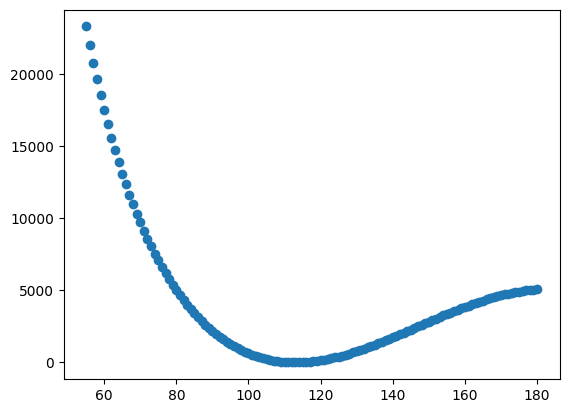

In [38]:
apoh_coords, E_apoh = load_coords_energy('apoh_1d.txt')
apoh = apoh_coords[:,4]*np.pi/180
w = (np.tanh(-0.008*(E_apoh - 2000)) + 1.002002002) / 2.002002002
#print(apoh)
#print(E_apoh)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh, 'o')
#plt.xlim(100,130)
#plt.ylim(-0.5, 1000)

## Reproduce original fits

Older fits have functional forms similar or close to a taylor expansion of the cos term:

$$ \cos(x) - \cos(x_e) $$

Often the fit is $ \cos(x_e) - \cos(x) $ since we instead fit $\rho = \pi - \beta $ instead of the actual bending angle $ \beta $. RMSD is around 0.9cm-1 weighted.

In [123]:
def power_term(x, xe):
    #return np.cos(x) - np.cos(xe)
    return x - xe

def cos_term(x, xe):
    return np.cos(x) - np.cos(xe)

def power_series(x, xe, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    z = power_term(x, xe)
    c = [c0, c1, c2, c3, c4, c5, c6, c7, c8]
    series = 0
    for i in range(9):
        series += c[i]*z**(i)

    return series 

def cos_series(x, xe, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    z = cos_term(x, xe)
    c = [c0, c1, c2, c3, c4, c5, c6, c7, c8]
    series = 0
    for i in range(9):
        series += c[i]*z**(i)

    return series 

def rmsd(obs, calc, weight):
    squared_diff = (obs-calc)**2
    weighted_mean_sqr = np.sum(weight*squared_diff)/np.sum(weight)
    return np.sqrt(weighted_mean_sqr)

def fit_evaluation(function, param_guess, weights):
    """This function fits a function to the bending energy data with given
       input parameters and given weights. Uses SciPy curvefit"""
    
    #perform fit
    p, cov = curve_fit(function, apoh, E_apoh, 
                       param_guess, 
                       sigma = 1/np.sqrt(weights))
    
    #print parameters obtained from fit
    print('Parameter Values:')
    print(np.round(p, 5))
    print()
    print('Parameter Error (%)')
    print(np.round(
    (np.sqrt(np.diag(cov))/p*100),
     3))
    
    #unpack parameters to predict energy, print RMSD 
    function_predict = function(apoh, *p)
    print()
    print(f'The RMSD is {rmsd(E_apoh, function_predict, weights)} cm-1')
    print()

    #print residuals
    with np.printoptions(precision=3, suppress=True, linewidth=100):
        print('Residuals:')
        print(E_apoh - function_predict)
    #leave space for plotting
    for i in range(3):
        print()
    #plot fit, calculations and residuals
    plt.figure()
    plt.plot(apoh*180/np.pi, function_predict)
    plt.plot(apoh*180/np.pi, E_apoh, '.')

    plt.figure()
    plt.plot(apoh*180/np.pi, E_apoh - function_predict)
    


Parameter Values:
[ 1.97289000e+00 -1.01022000e+00  1.07675408e+04 -6.30946983e+03
  5.24490640e+02 -1.04242543e+03  1.65202775e+03 -1.44664680e+03
  5.29805000e+02]

Parameter Error (%)
[ 3.0000e-03 -2.2276e+01  3.2000e-02 -1.6300e-01  2.7330e+00 -2.3070e+00
  1.3780e+00 -1.2320e+00  2.7350e+00]

The RMSD is 1.0331297707117009 cm-1

Residuals:
[77.953 57.59  41.411 28.765 19.07  11.812  6.539  2.859  0.433 -1.024 -1.756 -1.963 -1.81  -1.43
 -0.926 -0.379  0.152  0.625  1.012  1.299  1.479  1.554  1.533  1.426  1.247  1.014  0.743  0.448
  0.146 -0.15  -0.429 -0.68  -0.896 -1.07  -1.2   -1.283 -1.318 -1.307 -1.253 -1.16  -1.031 -0.873
 -0.692 -0.494 -0.286 -0.074  0.136  0.337  0.525  0.696  0.844  0.967  1.062  1.128  1.164  1.168
  1.143  1.088  1.005  0.898  0.769  0.622  0.459  0.287  0.108 -0.072 -0.249 -0.42  -0.578 -0.721
 -0.846 -0.948 -1.027 -1.078 -1.103 -1.098 -1.066 -1.006 -0.92  -0.81  -0.678 -0.529 -0.364 -0.19
 -0.01   0.171  0.349  0.517  0.673  0.81   0.924  1.013  1.0

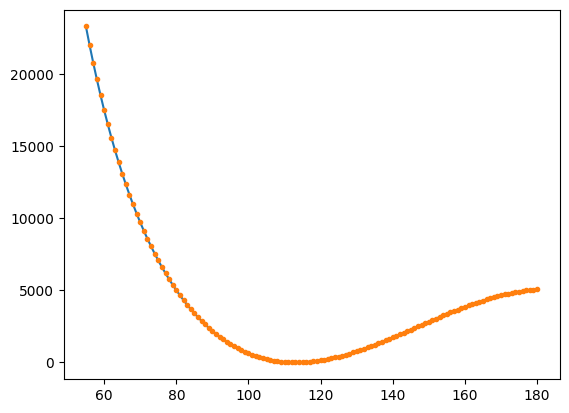

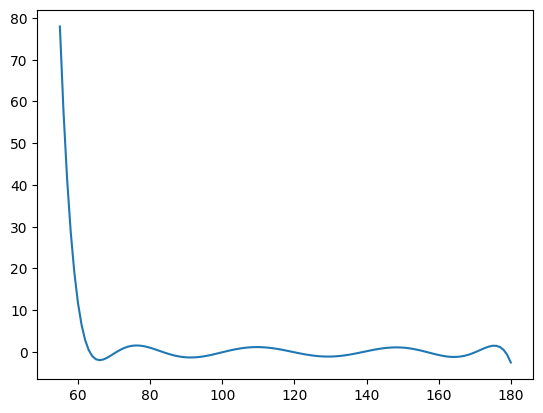

In [126]:
fit_evaluation(power_no_linear, original_params, power_weight)

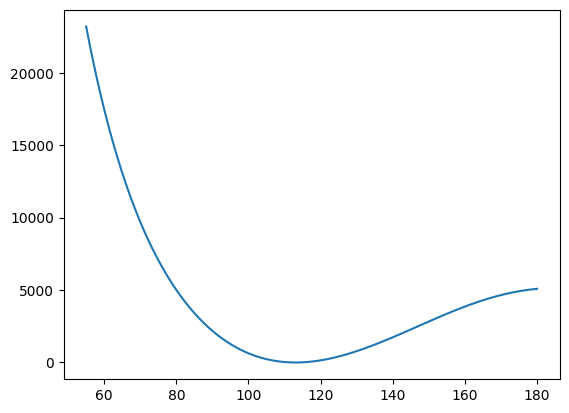

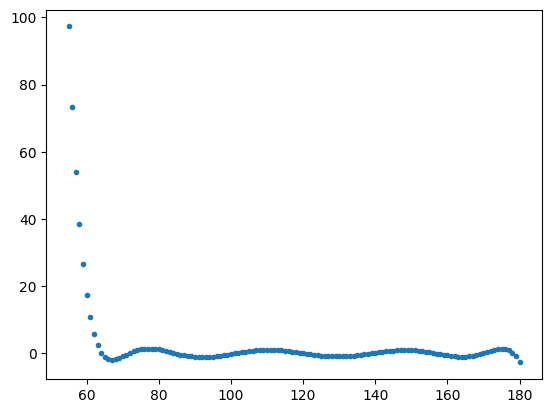

In [49]:
w = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
original_params = [1.974, -0.91334819, 10764.035, -6290.1980, 526.76432, -1098.6327, 
                   1669.8193, -1398.7498, 502.39223]

original_fit = power_series(apoh, 113.04244011*np.pi/180,
                          -0.91334819,
                          0,
                          10764.035, 
                          -6290.1980, 
                          526.76432, 
                          -1098.6327, 
                          1669.8193, 
                          -1398.7498, 
                          502.39223)

plt.figure()
plt.plot(apoh*180/np.pi, original_fit)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh - original_fit, '.')

In [47]:
print(f'The RMSD is {rmsd(E_apoh, original_fit, w)} cm-1')
print()

with np.printoptions(precision=3, suppress=True, linewidth=100):
    print('Residuals:')
    print(E_apoh - original_fit)


The RMSD is 1.1086512355151292 cm-1

Residuals:
[97.293 73.183 53.827 38.505 26.575 17.467 10.678  5.771  2.368  0.145 -1.173 -1.815 -1.972 -1.799
 -1.419 -0.931 -0.407  0.097  0.543  0.906  1.174  1.341  1.411  1.391  1.293  1.13   0.918  0.671
  0.405  0.132 -0.134 -0.384 -0.608 -0.8   -0.954 -1.067 -1.138 -1.166 -1.153 -1.102 -1.015 -0.898
 -0.756 -0.594 -0.418 -0.234 -0.047  0.136  0.311  0.473  0.618  0.743  0.846  0.923  0.974  0.997
  0.994  0.963  0.907  0.828  0.728  0.609  0.475  0.329  0.176  0.019 -0.137 -0.289 -0.433 -0.565
 -0.682 -0.781 -0.859 -0.914 -0.946 -0.953 -0.935 -0.892 -0.825 -0.737 -0.629 -0.504 -0.366 -0.217
 -0.062  0.095  0.25   0.398  0.536  0.658  0.761  0.842  0.897  0.925  0.922  0.89   0.826  0.733
  0.611  0.465  0.298  0.115 -0.077 -0.272 -0.461 -0.637 -0.791 -0.914 -0.996 -1.032 -1.013 -0.936
 -0.797 -0.599 -0.345 -0.047  0.282  0.616  0.925  1.168  1.291  1.23   0.902  0.212 -0.959 -2.748]


Now we test whether the SciPy fitting function can reproduce the fit provided by the Fortran program.

Parameter values:
[ 1.9730000e+00 -1.0100000e+00  1.0767541e+04 -6.3094700e+03
  5.2449100e+02 -1.0424260e+03  1.6520270e+03 -1.4466470e+03
  5.2980500e+02]
Error (%)
[ 3.0000e-03 -2.2276e+01  3.2000e-02 -1.6300e-01  2.7330e+00 -2.3070e+00
  1.3780e+00 -1.2320e+00  2.7350e+00]


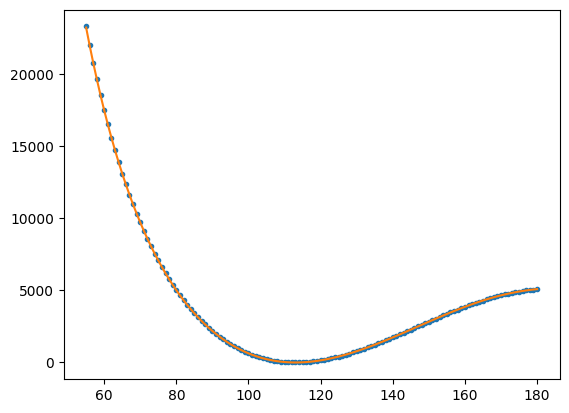

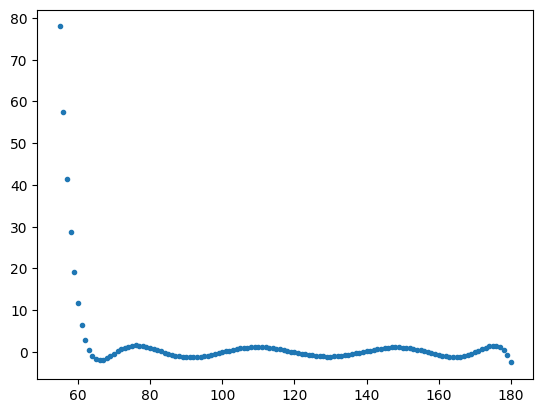

In [91]:
#fortran fit done without linear term
def power_no_linear(x, xe, c0, c2, c3, c4, c5, c6, c7, c8):
    return power_series(x, xe, c0, 0, c2, c3, c4, c5, c6, c7, c8)

power_weight = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
p_power, pcov_power = curve_fit(power_no_linear, apoh, E_apoh, 
                       [113.04244011*np.pi/180,
                          -0.91334819,
                          10764.035, 
                          -6290.1980, 
                          526.76432, 
                          -1098.6327, 
                          1669.8193, 
                          -1398.7498, 
                          502.39223],
                       sigma = 1/np.sqrt(power_weight)
                       )

print('Parameter values:')
print(np.round(p_power, 3))
print('Error (%)')
print(np.round((np.sqrt(np.diag(pcov_power))/p_power*100), 3))

power_predict = power_no_linear(apoh, p_power[0],
                          p_power[1],
                          p_power[2], 
                          p_power[3], 
                          p_power[4], 
                          p_power[5], 
                          p_power[6], 
                          p_power[7], 
                          p_power[8])
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh, '.')
plt.plot(apoh*180/np.pi, power_predict)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh - power_predict, '.')


In [118]:
print(f'The RMSD is {rmsd(E_apoh, power_predict, power_weight)} cm-1')
print()

with np.printoptions(precision=3, suppress=True, linewidth=100):
    print('Residuals:')
    print(E_apoh - power_predict)

The RMSD is 1.0331297707165898 cm-1

Residuals:
[77.953 57.59  41.411 28.765 19.07  11.812  6.539  2.859  0.433 -1.024 -1.756 -1.963 -1.81  -1.43
 -0.926 -0.379  0.152  0.625  1.012  1.299  1.479  1.554  1.533  1.426  1.247  1.014  0.743  0.448
  0.146 -0.15  -0.429 -0.68  -0.896 -1.07  -1.2   -1.283 -1.318 -1.307 -1.253 -1.16  -1.031 -0.873
 -0.692 -0.494 -0.286 -0.074  0.136  0.337  0.525  0.696  0.844  0.967  1.062  1.128  1.164  1.168
  1.143  1.088  1.005  0.898  0.769  0.622  0.459  0.287  0.108 -0.072 -0.249 -0.42  -0.578 -0.721
 -0.846 -0.948 -1.027 -1.078 -1.103 -1.098 -1.066 -1.006 -0.92  -0.81  -0.678 -0.529 -0.364 -0.19
 -0.01   0.171  0.349  0.517  0.673  0.81   0.924  1.013  1.071  1.098  1.091  1.049  0.971  0.861
  0.718  0.548  0.354  0.143 -0.08  -0.305 -0.524 -0.727 -0.906 -1.05  -1.149 -1.195 -1.18  -1.099
 -0.949 -0.73  -0.447 -0.111  0.261  0.647  1.01   1.309  1.486  1.472  1.179  0.504 -0.679 -2.518]


SciPy can reproduce the fit given the initial guess set to the already found linear parameters, we turn our attention to fitting new functional forms.

## New Fits

We now try morse-like fits:
$$ a(1-e^{b(\cos(x)-\cos(x_e))})^2 $$

In [110]:
#try fitting only one morse-like term
def morse_like(x, xe, b):
    return 1 - np.exp(b*(np.cos(x)-np.cos(xe)))

weight_morse_test = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
p_morse_test, pcov_morse_test = curve_fit(lambda x, xe, a, b: a*morse_like(x, xe, b)**2, apoh, E_apoh, 
                       [113.04244011*np.pi/180, 
                        10000, 
                        0.17],
                       sigma = 1/np.sqrt(weight_morse_test)
                       )
print('Parameter Values:')
print(np.round(p_morse_test, 5))
print()
print('Parameter Error (%)')
print(np.round(
    (np.sqrt(np.diag(pcov_morse_test))/p_morse_test*100),
     3))

Parameter Values:
[1.93361000e+00 7.08170066e+04 4.56660000e-01]

Parameter Error (%)
[0.216 8.835 4.304]


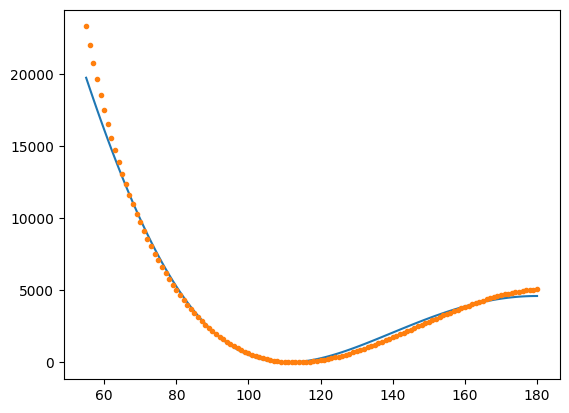

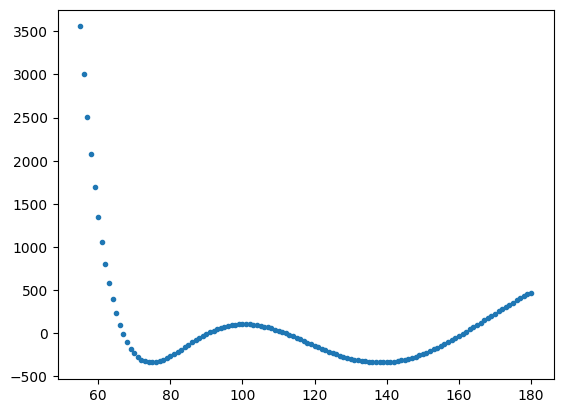

In [111]:
morse_test_predict = (lambda x, xe, a, b: a*morse_like(x, xe, b)**2)(
                        apoh,
                        p_morse_test[0],
                        p_morse_test[1],
                        p_morse_test[2] 
)

plt.figure()
plt.plot(apoh*180/np.pi, morse_test_predict)
plt.plot(apoh*180/np.pi, E_apoh, '.')

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh-morse_test_predict, '.')

The morse-like cosine term is reasonable, the residuals show there are still additional contributions required which is expected. The converged value of xe seems to be skewed by the asymmetry/higher energy points which puts it slightly offset from the minimum. 

The natural progression is to fit more higher order morse terms or combine with polynomial and cosine terms.

## Try more functional forms

In [115]:
def morse_polynomial(x, xe, a, b, c0, c2, c3, c4, c5, c6):
    series = a*morse_like(x, xe, b)**2
    c = [c0, c2, c3, c4, c5, c6]
    powers = [0, 2, 3, 4, 5, 6]
    for j in range(len(c)):
        series += c[j]*power_term(x, xe)**powers[j]
    return series

weight_morse_poly = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
p_morse_poly, pcov_morse_poly = curve_fit(morse_polynomial, apoh, E_apoh, 
                       [113.04244011*np.pi/180, 
                        7.08170066e+04, 
                        4.56660000e-01,
                        0,
                        0,
                        0,
                        0,
                        0,
                        0],
                       sigma = 1/np.sqrt(weight_morse_poly)
                       )

print('Parameter Values:')
print(np.round(p_morse_poly, 5))
print()
print('Parameter Error (%)')
print(np.round(
    (np.sqrt(np.diag(pcov_morse_poly))/p_morse_poly*100),
     3))

Parameter Values:
[ 1.97286000e+00  2.95801752e+06  2.15830000e-01 -6.11390000e-01
 -1.05940528e+05  6.64804725e+04  1.67903816e+04 -1.93738806e+04
  3.82628858e+03]

Parameter Error (%)
[ 2.0000e-03  1.0420e+00  9.2700e-01 -2.9298e+01 -1.3570e+00  1.6160e+00
  6.2200e-01 -1.2190e+00  1.8000e+00]


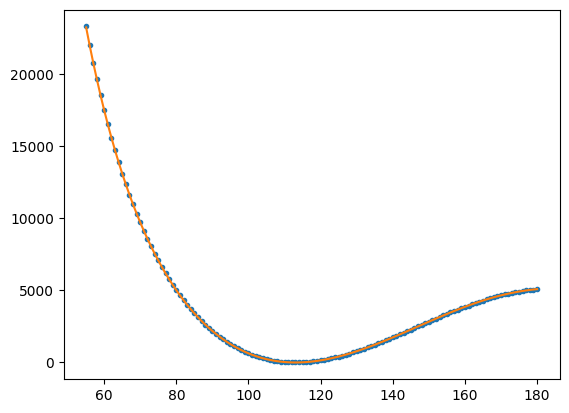

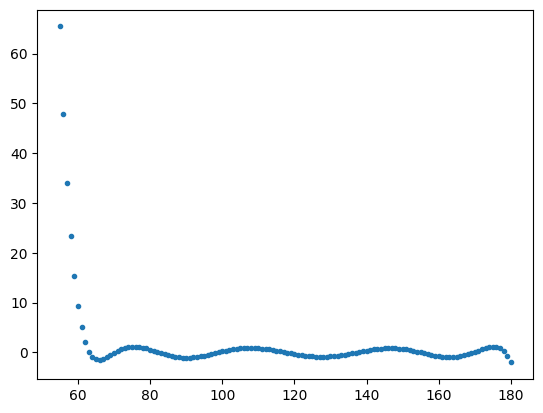

In [117]:
morse_poly_predict = morse_polynomial(apoh, p_morse_poly[0], p_morse_poly[1], p_morse_poly[2],
                          p_morse_poly[3],
                          p_morse_poly[4], 
                          p_morse_poly[5], 
                          p_morse_poly[6], 
                          p_morse_poly[7], 
                          p_morse_poly[8])
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh, '.')
plt.plot(apoh*180/np.pi, morse_poly_predict)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh - morse_poly_predict, '.')


In [119]:
print(f'The RMSD is {rmsd(E_apoh, morse_poly_predict, weight_morse_poly)} cm-1')
print()

with np.printoptions(precision=3, suppress=True, linewidth=100):
    print('Residuals:')
    print(E_apoh - morse_poly_predict)

The RMSD is 0.8045067370759941 cm-1

Residuals:
[65.427 47.9   34.096 23.411 15.308  9.316  5.026  2.087  0.198 -0.895 -1.401 -1.493 -1.312 -0.966
 -0.541 -0.101  0.309  0.657  0.925  1.104  1.194  1.199  1.129  0.996  0.814  0.596  0.358  0.113
 -0.127 -0.352 -0.553 -0.723 -0.858 -0.955 -1.012 -1.029 -1.009 -0.953 -0.865 -0.75  -0.613 -0.46
 -0.295 -0.125  0.045  0.21   0.365  0.507  0.631  0.734  0.815  0.872  0.904  0.911  0.894  0.853
  0.791  0.708  0.607  0.492  0.365  0.229  0.089 -0.053 -0.192 -0.326 -0.45  -0.563 -0.66  -0.741
 -0.802 -0.842 -0.861 -0.858 -0.833 -0.787 -0.72  -0.635 -0.534 -0.418 -0.291 -0.157 -0.018  0.122
  0.259  0.389  0.51   0.617  0.707  0.779  0.828  0.854  0.856  0.831  0.782  0.707  0.608  0.489
  0.351  0.198  0.035 -0.133 -0.3   -0.46  -0.607 -0.734 -0.835 -0.902 -0.931 -0.917 -0.857 -0.748
 -0.592 -0.391 -0.152  0.115  0.396  0.67   0.913  1.092  1.169  1.095  0.814  0.259 -0.65  -2.002]


In the above, we fit a function of the form:

$$ a(1-e^{b(\cos(x)-\cos(x_e))})^2 + c_0 + c_2 (x-x_e)^2 + c_3 (x-x_e)^3 + c_4 (x-x_e)^4 + c_5 (x-x_e)^5 + c_6 (x-x_e)^6$$

This achieves a fit marginally better than the polynomial fit. The fit can't extrapolate the left side well (growth is too slow), which suggests higher order morse growth needed. 

[7.99666472e+03 2.17645624e+00]


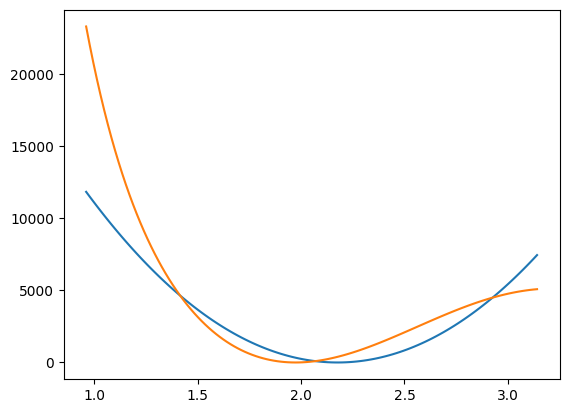

In [120]:
popt, pcov = curve_fit(lambda x, a, xe: a*(x-xe)**2, apoh, E_apoh, 
                       [10000, 1.97],
                       sigma = 1/w
                       )
print(popt)

plt.figure()
plt.plot(apoh, (lambda x, a, xe: a*(x-xe)**2)(apoh, popt[0], popt[1]))
plt.plot(apoh, E_apoh)

[2.20294680e+05 2.56924780e-01 1.96316954e+00]
112.48132931889697
[3.27133866e+04 1.89922138e-02 3.39399122e-03]


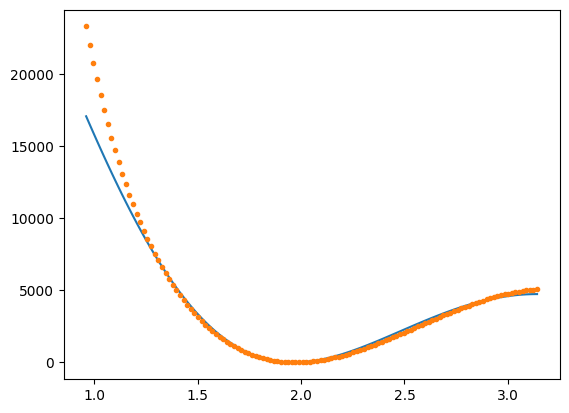

In [66]:
w = (np.tanh(-0.008*(E_apoh - 10000)) + 1.002002002) / 2.002002002
popt, pcov = curve_fit(lambda x, a, b, xe: a*(1-np.exp(b*(np.cos(x)-np.cos(xe))))**2, apoh, E_apoh, 
                       [10000, 1.5, 1.97],
                       sigma = 1/w
                       )
print(popt)
print(popt[2]*180/np.pi)
print(np.sqrt(np.diag(pcov)))

predict_apoh = (lambda x, a, b, xe: 
                a*(1-np.exp(b*(np.cos(x)-np.cos(xe))))**2)(apoh, popt[0], popt[1], popt[2])
plt.figure()
plt.plot(apoh, predict_apoh)
plt.plot(apoh, E_apoh, '.')

150.80431850404995


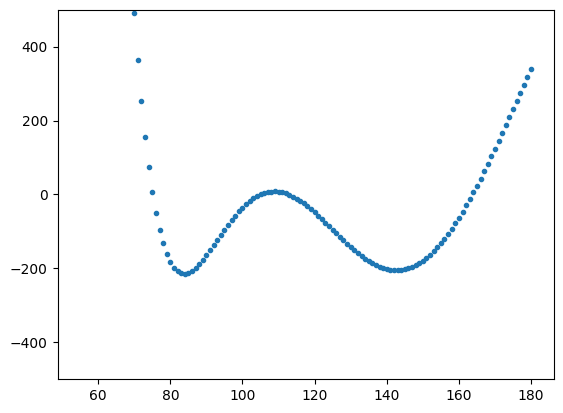

In [67]:
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh-predict_apoh, '.')
plt.ylim(-500,500)

print(np.sqrt(np.sum(((E_apoh-predict_apoh)*(np.sqrt(w)))**2)/len(E_apoh)))

[ 1.96807033e+00  3.15849438e-01  1.23901934e+05 -9.20394853e+00
  8.54224439e+02  5.33181130e+01 -1.38041120e+03 -3.63675752e+03
  1.37867131e+04]
112.76212386287936
[1.00776864e-03 9.12592846e+01 1.61212648e+08 4.78031850e+00
 1.01707126e+07 2.52975140e+06 4.12721279e+05 6.25946239e+04
 9.65020494e+03]


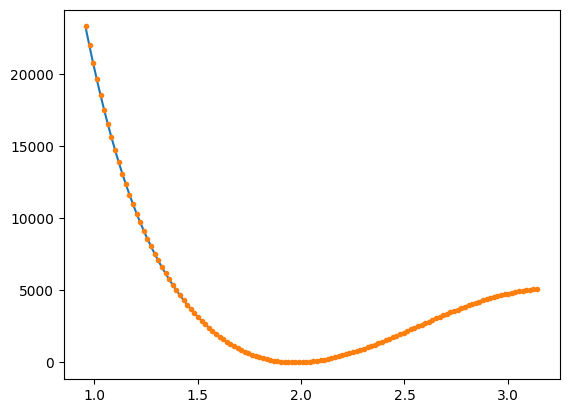

In [10]:
def morse_cos(x, xe, a):
    return 1 - np.exp(a*(np.cos(x)-np.cos(xe)))

def morse_fit(x, xe, a, b, c0, c2, c3, c4, c5, c6):
    z = morse_cos(x, xe, a)**2
    y = np.cos(x) - np.cos(xe)

    return b*z + c0 + c2*y**2 + c3*y**3 + c4*y**4 + c5*y**5 + c6*y**6


w = (np.tanh(-0.008*(E_apoh - 20000)) + 1.002002002) / 2.002002002
popt, pcov = curve_fit(morse_fit, apoh, E_apoh, 
                       [1.974, 0.166, 70000, 20, 2000, 1000, 500, 2000, 1000],
                       sigma = 1/w
                       )

print(popt)
print(popt[0]*180/np.pi)
print(np.sqrt(np.diag(pcov)))


predict_apoh = morse_fit(apoh, popt[0], popt[1], popt[2], popt[3], popt[4], popt[5], popt[6], popt[7], popt[8])
plt.figure()
plt.plot(apoh, predict_apoh)
plt.plot(apoh, E_apoh, '.')

[ 7.47911534e+00  4.85925617e+00  2.89171008e+00  4.57173850e+01
  1.39901558e+01 -6.83425954e+00 -1.90764018e+01 -2.47753379e+01
 -2.56580013e+01 -2.31684591e+01 -1.84960680e+01 -1.26027713e+01
 -6.24896330e+00 -1.81907443e-02  5.65971207e+00  1.04867437e+01
  1.42768034e+01  1.69368741e+01  1.84501675e+01  1.88606896e+01
  1.82592446e+01  1.67710633e+01  1.45447956e+01  1.17429063e+01
  8.53328675e+00  5.08232945e+00  1.54893607e+00 -1.91999749e+00
 -5.19333166e+00 -8.15828811e+00 -1.07221449e+01 -1.28131279e+01
 -1.43807376e+01 -1.53951581e+01 -1.58465589e+01 -1.57435180e+01
 -1.51115496e+01 -1.39909183e+01 -1.24346735e+01 -1.05061474e+01
 -8.27666698e+00 -5.82310920e+00 -3.22545222e+00 -5.64555275e-01
  2.08004111e+00  4.63220203e+00  7.02090881e+00  9.18192755e+00
  1.10591169e+01  1.26054340e+01  1.37839003e+01  1.45679370e+01
  1.49418249e+01  1.49006837e+01  1.44501625e+01  1.36061897e+01
  1.23942097e+01  1.08484155e+01  9.01082582e+00  6.93010403e+00
  4.66032406e+00  2.25971

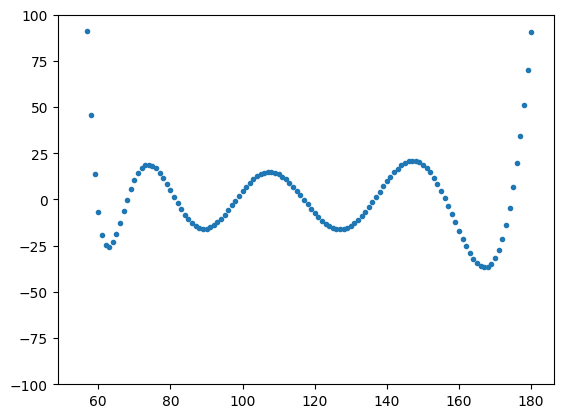

In [11]:
plt.figure()
plt.plot(apoh*180/np.pi, E_apoh-predict_apoh, '.')
plt.ylim(-100,100)

#print(E_apoh - predict_apoh)
print((E_apoh-predict_apoh)*(np.sqrt(w)))

print(np.sqrt(np.sum(((E_apoh-predict_apoh)*(np.sqrt(w)))**2)/len(E_apoh)))